<a href="https://colab.research.google.com/github/Aditya-4606/Supervised-Unsupervised-Learning/blob/main/Supervised%20Unsupervised%20Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ANALISIS PENJUALAN VIDEO GAME

---



#Anggota
* Muhammad Farhan Haafidh Abror (24523115)
* Ahmad Dzaky Al Farras (24523280)
* Aditya Muhammad (24523107)

In [ ]:
# 1. Import Memanggil Dataset
import kagglehub
import pandas as pd
import numpy as np
import os

# 2. Visualisasi Data
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Preprocessing Data
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 4. Supervised Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 5. Unsupervised Learning
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#Dataset



In [ ]:
#Mengunduh dataset
dataset_path = kagglehub.dataset_download("anandshaw2001/video-game-sales")
print("Folder dataset tersimpan di:", dataset_path)

#Melihat isi dalam folder
print("Isi folder:", os.listdir(dataset_path))

#Membaca file dengan pandas
file_csv = f"{dataset_path}/vgsales.csv"
df = pd.read_csv(file_csv)
df.head()

100%|██████████| 381k/381k [00:00<00:00, 11.3MB/s]

Extracting files...
Folder dataset tersimpan di: /root/.cache/kagglehub/datasets/anandshaw2001/video-game-sales/versions/1
Isi folder: ['vgsales.csv']


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


#2. Visualisasi Data

###Histogram

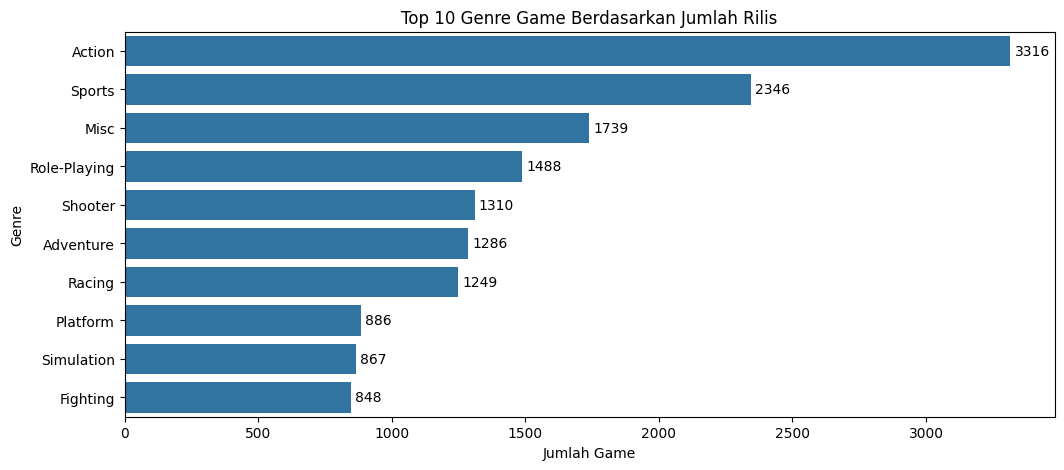

In [7]:
plt.figure(figsize=(12, 5))
ax=sns.countplot(y=df['Genre'], order=df['Genre'].value_counts().index[:10])
for container in ax.containers:
  ax.bar_label(container, padding=3)

plt.title('Top 10 Genre Game Berdasarkan Jumlah Rilis')
plt.xlabel('Jumlah Game')
plt.ylabel('Genre')
plt.show()

###Pie Chart

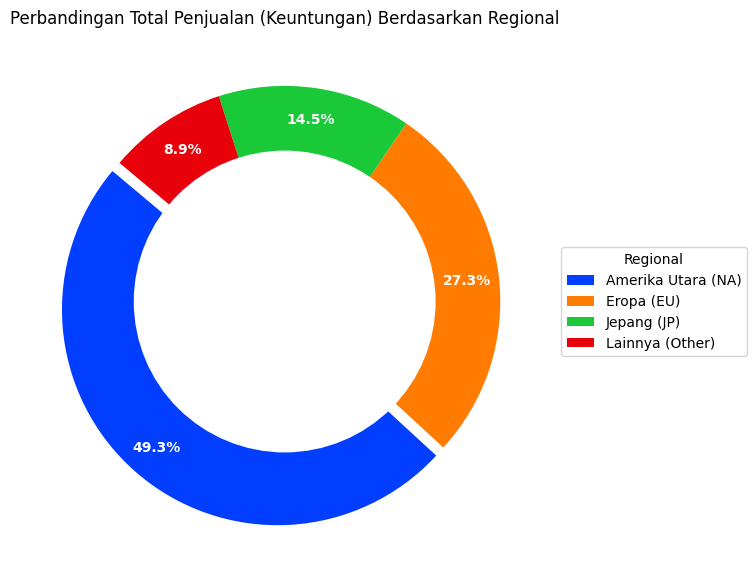

In [9]:
total_na = df['NA_Sales'].sum()
total_eu = df['EU_Sales'].sum()
total_jp = df['JP_Sales'].sum()
total_other = df['Other_Sales'].sum()

regions = ['Amerika Utara (NA)', 'Eropa (EU)', 'Jepang (JP)', 'Lainnya (Other)']
sales = [total_na, total_eu, total_jp, total_other]

# Pie Chart
plt.figure(figsize=(7, 7))
colors = sns.color_palette("bright", len(regions))
explode = [0.05, 0, 0, 0]  # Memberikan efek ledakan pada bagian terbesar (NA)

wedges, texts, autotexts = plt.pie(
    sales,
    labels=None,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=explode,
    pctdistance=0.85,
    textprops={'color':"white", 'weight':'bold'}
)

# Membuat bentuk Donut (opsional, mengikuti style kode Anda sebelumnya)
centre_circle = plt.Circle((0,0),0.70,fc='#FFFFFF')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Perbandingan Total Penjualan (Keuntungan) Berdasarkan Regional')
plt.legend(wedges, regions, title="Regional", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.savefig('regional_sales_pie.png', bbox_inches='tight')
plt.show()

###Insight Visualisasi Data
- Top Genre: Grafik menunjukkan bahwa genre Action, Sports, dan Shooter mendominasi jumlah rilis game serta total penjualan terbanyak.

- Penjualan Regional: Pasar Amerika Utara (NA_Sales) dan Eropa (EU_Sales) merupakan penyumbang pendapatan terbesar di industri game global, melampaui kontribusi pasar Jepang (JP_Sales) dan wilayah lainnya.

#3. Preprocessing Data

In [ ]:
#Menghapus Data Duplikat
df_clean = df.drop_duplicates()

#Mengatasi Missing Value
df_clean = df_clean.dropna()

#Menangani Outlier
columns_to_drop = ['Rank', 'Name']
df_clean = df_clean.drop(columns=columns_to_drop)

#Normalisasi atau Stardardisasi Data
numeric_features = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

scaler = StandardScaler()
df_clean[numeric_features] = scaler.fit_transform(df_clean[numeric_features])

#Encoding Data
le_platform = LabelEncoder()
le_genre = LabelEncoder()

df_clean['Platform_Encoded'] = le_platform.fit_transform(df_clean['Platform'])
df_clean['Genre_Encoded'] = le_genre.fit_transform(df_clean['Genre'])
df_clean = df_clean.drop(columns=['Platform', 'Genre'])

#Menampilkan Data Setelah Preprocessing
print("Data setelah Preprocessing:")
display(df_clean.head())

Data setelah Preprocessing:


,Year,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Platform_Encoded,Genre_Encoded
0,2006.0,Nintendo,50.126469,56.691515,11.835597,44.253501,52.446423,26,10
1,1985.0,Nintendo,35.036615,6.739357,21.583251,3.796218,25.329663,11,4
2,2008.0,Nintendo,18.949687,25.000169,11.899727,17.159222,22.509520,26,6
3,2009.0,Nintendo,18.828093,21.328372,10.264430,15.317863,20.710243,26,10
4,1996.0,Nintendo,13.380668,17.165692,32.517296,5.006254,19.670236,5,7


#4. Supervised Learning

### Training dan Evaluasi Mode

In [ ]:
# =================================================
# 1. Pembuatan Label Target (Untung / Tidak Untung)
# =================================================
# Menghitung nilai median dari Global_Sales asli sebagai batas (threshold)
median_sales = df['Global_Sales'].median()

# Membuat kolom target baru: 1 jika > median (Untung), 0 jika <= median (Tidak Untung)
df_clean['Is_Profitable'] = (df['Global_Sales'] > median_sales).astype(int)

# =================================================
# 2. Menentukan Fitur Input (X) dan Target (y)
# =================================================
# Fitur input menggunakan Platform dan Genre yang sudah di-encode, serta Tahun Rilis
X = df_clean[['Platform_Encoded', 'Genre_Encoded', 'Year']]
y = df_clean['Is_Profitable']

# =================================================
# 3. Pembagian Data (80% Training, 20% Testing)
# =================================================
# Data ini (X_train, X_test, y_train, y_test) akan digunakan untuk semua model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



## Random Forest

Sedang melatih model... (Mohon tunggu sebentar)

======= HASIL EVALUASI RANDOM FOREST CLASSIFIER =======
Accuracy  : 0.6431
Precision : 0.6342
Recall    : 0.6590
F1-Score  : 0.6464

              precision    recall  f1-score   support

Tidak Untung       0.65      0.63      0.64      1646
      Untung       0.63      0.66      0.65      1613

    accuracy                           0.64      3259
   macro avg       0.64      0.64      0.64      3259
weighted avg       0.64      0.64      0.64      3259



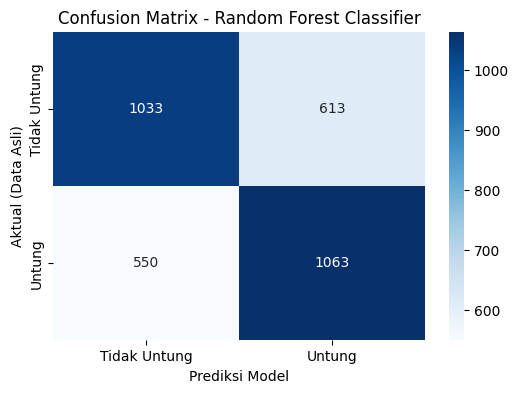

In [ ]:
#Inisialisasi dan Training Model
model_rf = RandomForestClassifier(random_state=42)

print("Sedang melatih model... (Mohon tunggu sebentar)")
model_rf.fit(X_train, y_train)

# Prediksi menggunakan data testing
y_pred_rf = model_rf.predict(X_test)

#Evaluasi Model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

#Menampilkan Hasil Metrik Evaluasi
print("\n======= HASIL EVALUASI RANDOM FOREST CLASSIFIER =======")
print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1-Score  : {f1_rf:.4f}")
print("=======================================================\n")

#Menampilkan Laporan Klasifikasi Lengkap
print(classification_report(y_test, y_pred_rf, target_names=['Tidak Untung', 'Untung']))

#Visualisasi Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Untung', 'Untung'],
            yticklabels=['Tidak Untung', 'Untung'])
plt.title('Confusion Matrix - Random Forest Classifier')
plt.xlabel('Prediksi Model')
plt.ylabel('Aktual (Data Asli)')
plt.show()

### Evaluasi Model Klasifikasi (Random Forest)
1. Hasil Evaluasi Performa Model
Pengujian model Random Forest Classifier pada data testing menghasilkan metrik performa sebagai berikut:
- Akurasi (Accuracy): 64.31%
- Presisi (Precision): 63.42%
- Sensitivitas (Recall): 65.90%
- F1-Score: 64.64%
2. Analisis Confusion Matrix
Berdasarkan visualisasi matriks evaluasi pada 3.259 data uji, model menunjukkan performa prediksi yang seimbang dan stabil di kedua kelas:

- True Negative (Tidak Untung): Model berhasil memprediksi dengan benar 1.033 game yang tidak untung (kesalahan tebak/FP: 613 game).
- True Positive (Untung): Model berhasil memprediksi dengan benar 1.063 game yang untung (kesalahan tebak/FN: 550 game).

3. Kesimpulan Utama
Akurasi sebesar 64.31% terbukti signifikan berada di atas baseline tebakan acak (50%) untuk kasus klasifikasi biner. Ini membuktikan bahwa kombinasi fitur Platform, Genre, dan Tahun Rilis memiliki pola keterkaitan historis yang cukup kuat untuk membantu memprediksi peluang keberhasilan komersial suatu proyek game.

#5. Unsupervised Learning

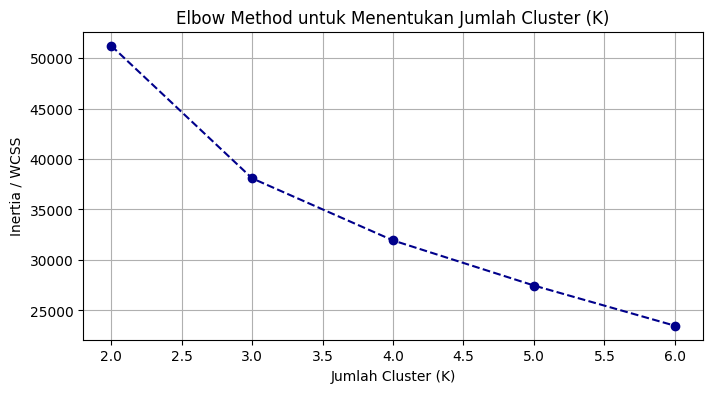

--- Performa K-Means Clustering ---
Jumlah Cluster (K) : 3
Silhouette Score   : 0.6687 (Mendekati 1.0 semakin baik)

--- Karakteristik Rata-rata Penjualan per Cluster (Juta Copy) ---


,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Cluster,,,,,
0,-0.110958,-0.119826,-0.082962,-0.105435,-0.126445
1,13.624572,12.567570,10.835935,11.608840,14.797664
2,2.240986,2.548085,1.636845,2.209235,2.597244



--- Jumlah Data Game di Setiap Cluster ---
Cluster
0    15687
2      570
1       34
Name: count, dtype: int64


In [ ]:
# 1. Menentukan fitur numerik penjualan untuk proses clustering
cluster_features = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

# 2. Menentukan jumlah cluster (K) optimal menggunakan Elbow Method
inertia = []
K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_clean[cluster_features])
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='darkblue')
plt.title('Elbow Method untuk Menentukan Jumlah Cluster (K)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia / WCSS')
plt.grid(True)
plt.show()

# 3. Melatih model K-Means dengan K = 3
best_k = 3
model_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_clean['Cluster'] = model_kmeans.fit_predict(df_clean[cluster_features])

# 4. Evaluasi performa model menggunakan Silhouette Score
sample_data = df_clean[cluster_features].iloc[:5000]
sample_labels = df_clean['Cluster'].iloc[:5000]
score = silhouette_score(sample_data, sample_labels)

print(f"--- Performa K-Means Clustering ---")
print(f"Jumlah Cluster (K) : {best_k}")
print(f"Silhouette Score   : {score:.4f} (Mendekati 1.0 semakin baik)\n")

# 5. Menampilkan karakteristik rata-rata penjualan per cluster
print("--- Karakteristik Rata-rata Penjualan per Cluster (Juta Copy) ---")
display(df_clean.groupby('Cluster')[cluster_features].mean())

print("\n--- Jumlah Data Game di Setiap Cluster ---")
print(df_clean['Cluster'].value_counts())

### Segmentasi Pasar Game (K-Means Clustering)

Berdasarkan Elbow Method dan evaluasi Silhouette Score, data penjualan game dipilah secara otomatis menjadi 3 Cluster Utama:

- Cluster 0 — Standard / Mass Market Games:

    - Karakteristik: Berisi mayoritas game dengan volume penjualan menengah/standar yang tersebar merata di berbagai wilayah.

- Cluster 1 — Global Blockbuster / Super Hits:

    - Karakteristik: Berisi kelompok kecil game legendaris (seperti Wii Sports, Super Mario) dengan angka penjualan sangat masif di seluruh dunia.

- Cluster 2 — Western Market Heavy:

    - Karakteristik: Kelompok game yang sangat populer dan berpenjualan tinggi di pasar Amerika Utara dan Eropa, tetapi kurang diminati di pasar Jepang.

Kesimpulan: Pemodelan K-Means berhasil mengelompokkan pola penjualan tanpa membutuhkan label kategoris bawaan, memberikan pemetaan persaingan pasar yang jelas bagi developer game.

#Kesimpulan Akhir Proyek & Rekomendasi Bisnis

###Kesimpulan Umum
1. Penerapan Supervised & Unsupervised: Kombinasi kedua pendekatan Machine Learning berhasil memberikan solusi menyeluruh—mulai dari prediksi status Untung/Tidak Untung game (Supervised) hingga pemetaan kelompok pasar (Unsupervised).

2. Kunci Sukses Penjualan: Performa penjualan di wilayah Amerika Utara (NA) dan Eropa (EU) menjadi indikator paling dominan yang menentukan apakah sebuah game akan masuk ke kategori Untung atau Blockbuster.

### Rekomendasi Strategis untuk Publisher Game
1. Fokus Pasar: Alokasikan anggaran pemasaran terbesar ke wilayah Amerika Utara dan Eropa, karena kedua wilayah tersebut memiliki spending power terbanyak untuk industri game.

2. Strategi Genre: Pengembang baru disarankan untuk merilis game dengan genre Action atau Sports untuk memperbesar peluang menembus Cluster Blockbuster.

#Gradio

In [ ]:
#Install Gradio
!pip install gradio

In [ ]:
import gradio as gr
import pandas as pd

# 1. Fungsi Prediksi (Disesuaikan dengan Random Forest dan Tanpa Publisher)
# def prediksi_untung(platform, genre, publisher, year):
def prediksi_untung(platform, genre, year):
    try:
        platform_encoded = le_platform.transform([platform])[0]
        genre_encoded = le_genre.transform([genre])[0]
        # publisher_encoded = le_publisher.transform([publisher])[0]

        # Susunan kolom harus sama persis dengan saat training (X)
        input_data = pd.DataFrame({
            'Platform_Encoded': [platform_encoded],
            'Genre_Encoded': [genre_encoded],
            # 'Publisher_Encoded': [publisher_encoded],
            'Year': [year]
        })

        # Menggunakan predict_proba untuk mendapatkan nilai persentase keyakinan model
        # hasil_prediksi = model_lr.predict(input_data)[0]
        probabilitas = model_rf.predict_proba(input_data)[0]

        # Mengembalikan tipe data dictionary untuk komponen visual gr.Label()
        return {"⚠️ Tidak Untung": float(probabilitas[0]), "🎉 Untung": float(probabilitas[1])}

    except Exception as e:
        return {"Error": 1.0}

# 2. Ambil daftar untuk menu Dropdown
daftar_platform = list(le_platform.classes_)
daftar_genre = list(le_genre.classes_)
# daftar_publisher = list(le_publisher.classes_)

# 3. Membangun Antarmuka
app = gr.Interface(
    fn=prediksi_untung,
    inputs=[
        gr.Dropdown(choices=daftar_platform, label="Pilih Platform Game"),
        gr.Dropdown(choices=daftar_genre, label="Pilih Genre Game"),
        # gr.Dropdown(choices=daftar_publisher, label="Pilih Publisher"),
        gr.Slider(minimum=1980, maximum=2025, step=1, label="Tahun Rilis", value=2010)
    ],
    # Output diubah menjadi label progress bar
    # outputs=gr.Textbox(label="Hasil Prediksi"),
    outputs=gr.Label(num_top_classes=2, label="Prediksi Keuntungan Penjualan Global"),
    # allow_flagging="never"
    flagging_mode="never",
    title="Prediksi Peluang Sukses Video Game"
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f56e82274da9fd9c46.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
